In [4]:
import sys 
sys.path.append("../../../src/")
from common_imports import *
from equilibrium_critical_correlations import *

In [67]:

#P_n correlations do not calculate connected correlator at all
def P_n_correlations(n,l,even=True):
    #Term 1 
    indices =  [i for i in range(0,n)]
    #Term 2 
    indices += [i for i in range(l,n+l)]
    terms = kb.all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(sigma_general(indices))*degen)
        else:
            dat.append(sigma_general(indices)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


In [68]:
def G(r,n):
    P0 = P_n(n)
    Var = P0*(1-P0)
    data=[]
    for ri in r:
        PP = P_n_correlations(n,ri)-P0**2
        data.append(PP/Var)
    return array(data)


In [77]:
r = np.arange(0,50)
ns = np.arange(1,10)

In [78]:
data= [G(r,ni) for ni in tqdm(ns)]

  0%|          | 0/9 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 9/9 [10:28<00:00, 69.87s/it] 


(0.0, 50.0)

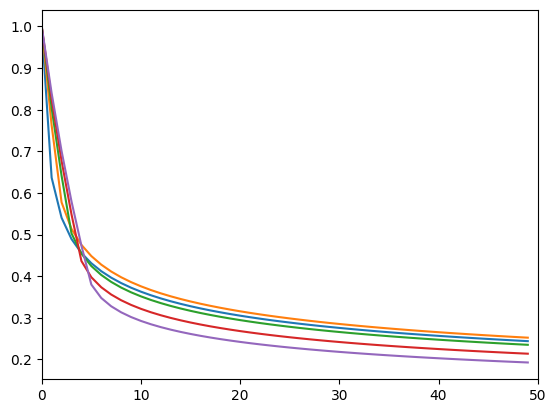

In [76]:
for d in data:
    plot(r,d)
xlim(0,50)
#loglog()